# Bài tập buổi 6 — Hồi quy tuyến tính

**Sinh viên thực hiện:** Nguyễn Huỳnh Nam Quốc - 2453089


---

## Bối cảnh

Trong bài tập này, bạn sẽ làm việc với bộ dữ liệu **California Housing** (Dự đoán giá nhà tại California dựa trên các đặc trưng nhân khẩu học và địa lý). Bài toán đặt ra là bài toán **Hồi quy (Regression)**.

Nhiệm vụ của bạn là xây dựng luồng xử lý dữ liệu và huấn luyện 3 biến thể của Hồi quy tuyến tính:
1. **Vanilla Linear Regression** (Hồi quy tuyến tính thông thường)
2. **Ridge Regression** (Hồi quy với chuẩn hóa L2)
3. **Lasso Regression** (Hồi quy với chuẩn hóa L1)

## Mục tiêu bài tập

1. Thực hiện Load dữ liệu và Khám phá dữ liệu (EDA) cơ bản.
2. Chia tập Train/Test và tiền xử lý (Scaling) đúng chuẩn, không gây Data Leakage.
3. Huấn luyện và đánh giá mô hình bằng các metric chuẩn cho Regression (RMSE, R²).
4. **Trực quan hóa hệ số hồi quy (Coefficients)** để hiểu rõ tính chất thu nhỏ (shrinkage) của Ridge và khả năng chọn lọc đặc trưng (feature selection) của Lasso.

---


## 0. Chuẩn bị môi trường & Import Thư viện

Ô này chứa sẵn các thư viện cần thiết. Nếu bạn cần dùng thêm thư viện nào, hãy bổ sung vào đây.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)  # Cố định random seed
print("Đã import xong thư viện.")

Đã import xong thư viện.


---
## Task 1 — Tải dữ liệu và Khám phá ban đầu (EDA)

### Yêu cầu
1. Tải bộ dữ liệu `California Housing` từ `sklearn.datasets`.
2. Chuyển đổi thành pandas DataFrame. Gán cột target là `MedHouseVal` (Giá nhà trung bình - đơn vị trăm nghìn USD).
3. In ra số dòng, số cột (shape) và thông tin kiểu dữ liệu (`.info()`).
4. Kiểm tra xem có giá trị thiếu (Missing values) nào trong bộ dữ liệu không.

### Gợi ý
- Hàm `fetch_california_housing(as_frame=True)` hỗ trợ trả về DataFrame trực tiếp qua thuộc tính `.frame`.
- Dùng `df.isnull().sum()` để đếm số lượng giá trị thiếu cho mỗi cột.

In [10]:
# TODO 1: Load dữ liệu, tạo DataFrame và kiểm tra tổng quan
california = fetch_california_housing(as_frame=True)

df = california.frame.copy()

# In shape, info và kiểm tra missing values
print("Shape của dataset:", df.shape)

print("\n5 dòng đầu:")
display(df.head())

print("\nThông tin dữ liệu:")
df.info()

print("\nSố lượng missing values theo từng cột:")
display(df.isnull().sum())

Shape của dataset: (20640, 9)

5 dòng đầu:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Số lượng missing values theo từng cột:


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

**Nhận xét Task 1:**

Dataset California Housing gồm các đặc trưng như thu nhập trung bình, tuổi nhà, số phòng, dân số và vị trí địa lý. Biến mục tiêu là `MedHouseVal`, tức giá nhà trung bình theo đơn vị trăm nghìn USD.

Em thấy dữ liệu đã ở dạng số và không có missing values, nên có thể chuyển sang bước chia train/test và scale dữ liệu mà không cần xử lý thiếu.

---
## Task 2 — Trực quan hóa Phân phối & Tương quan

### Yêu cầu
1. Vẽ biểu đồ Histogram (có đường cong KDE) cho biến mục tiêu `MedHouseVal`. Nhận xét xem phân phối có bị lệch (skew) không.
2. Vẽ ma trận tương quan (Heatmap) giữa tất cả các biến số trong dữ liệu.
3. **Trả lời:** Đặc trưng nào có độ tương quan dương mạnh nhất với giá nhà (`MedHouseVal`)?

### Gợi ý
- Sử dụng `sns.histplot(data=df, x='MedHouseVal', kde=True)` để vẽ phân phối.
- Dùng `df.corr()` để tính ma trận tương quan và đưa vào `sns.heatmap(..., annot=True, cmap='coolwarm', fmt=".2f")` để vẽ biểu đồ nhiệt.

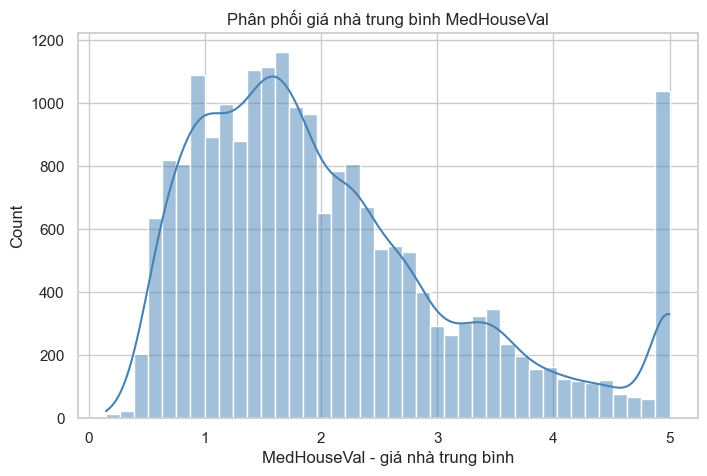

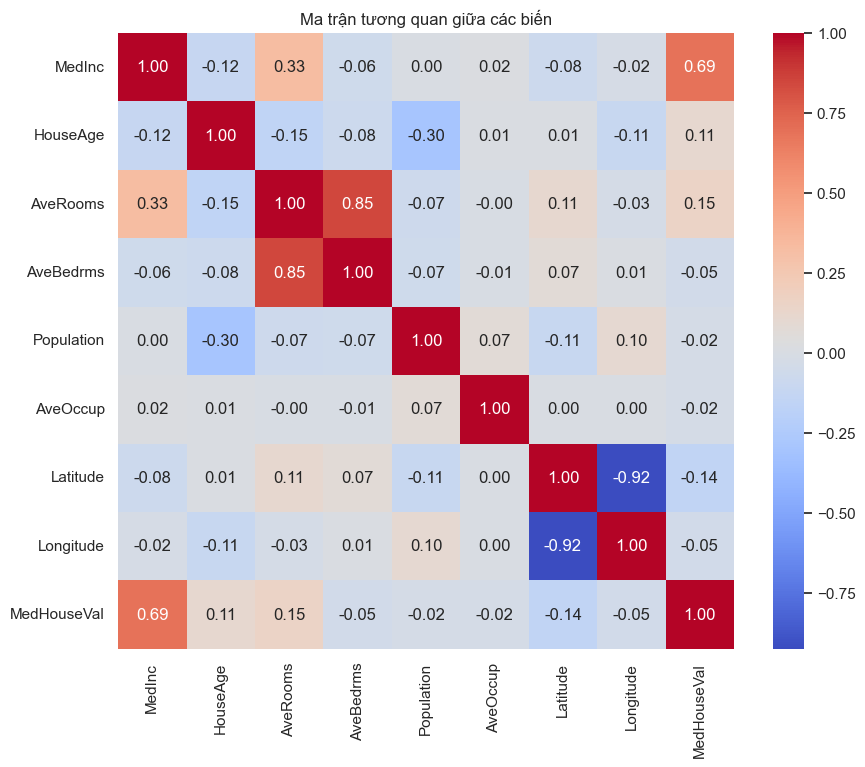

Tương quan của các đặc trưng với MedHouseVal:


MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64

Biến tương quan dương mạnh nhất với MedHouseVal: MedInc = 0.6881


In [11]:
# TODO 2a: Vẽ Histogram cho biến MedHouseVal
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="MedHouseVal", kde=True, bins=40, color="steelblue")

plt.title("Phân phối giá nhà trung bình MedHouseVal")
plt.xlabel("MedHouseVal - giá nhà trung bình")
plt.ylabel("Count")
plt.show()


# TODO 2b: Vẽ Heatmap correlation cho toàn bộ dữ liệu
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Ma trận tương quan giữa các biến")
plt.show()

target_corr = corr_matrix["MedHouseVal"].drop("MedHouseVal").sort_values(ascending=False)

print("Tương quan của các đặc trưng với MedHouseVal:")
display(target_corr)

strongest_positive_feature = target_corr.idxmax()
strongest_positive_corr = target_corr.max()

print(
    f"Biến tương quan dương mạnh nhất với MedHouseVal: "
    f"{strongest_positive_feature} = {strongest_positive_corr:.4f}"
)

**Trả lời 2:**

Phân phối của `MedHouseVal` không hoàn toàn giống phân phối chuẩn. Em thấy giá nhà tập trung nhiều ở vùng thấp đến trung bình, nhưng có một cụm khá rõ ở giá trị cao nhất khoảng 5. Điều này có thể do dữ liệu bị giới hạn trần giá trị, nên nhiều mẫu bị dồn ở mức giá tối đa.

Từ ma trận tương quan, đặc trưng có tương quan dương mạnh nhất với `MedHouseVal` là `MedInc`. Điều này khá hợp lý vì khu vực có thu nhập trung bình cao hơn thường có giá nhà trung bình cao hơn.

---
## Task 3 — Chia tập dữ liệu và Tiền xử lý (Scaling)

Với các mô hình có sử dụng Regularization như Ridge và Lasso, việc **Scale dữ liệu** (đưa về cùng thang đo) là **BẮT BUỘC**. Nếu không scale, các đặc trưng có miền giá trị lớn (ví dụ như Population) sẽ lấn át các đặc trưng có miền giá trị nhỏ, làm sai lệch tác dụng của hệ số phạt L1/L2.

### Yêu cầu
1. Tách features (`X`) và target (`y`).
2. Chia tập Train/Test theo tỷ lệ **80/20**.
3. Dùng `StandardScaler` để scale tập `X`. **Quan trọng:** Chỉ `.fit()` trên `X_train`, sau đó dùng tham số đã học đó để `.transform()` cho cả `X_train` và `X_test`.

### Gợi ý
- `train_test_split(X, y, test_size=0.2, random_state=42)`.
- `scaler.fit_transform(X_train)` cho tập train và `scaler.transform(X_test)` cho tập test.

In [12]:
# TODO 3: Chia tập và Scale dữ liệu
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nMean của X_train_scaled:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nStd của X_train_scaled:")
print(np.round(X_train_scaled.std(axis=0), 4))

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)

Mean của X_train_scaled:
[-0. -0. -0. -0. -0.  0.  0.  0.]

Std của X_train_scaled:
[1. 1. 1. 1. 1. 1. 1. 1.]


**Nhận xét Task 3:**

Em chỉ `fit` StandardScaler trên `X_train`, sau đó dùng scaler đó để transform cả `X_train` và `X_test`. Cách này giúp tránh data leakage, vì thông tin của tập test không bị dùng trong quá trình học tham số scale.

Sau khi scale, các đặc trưng trong tập train có mean gần 0 và std gần 1. Điều này đặc biệt quan trọng với Ridge và Lasso vì hai mô hình này có regularization, nếu không scale thì các đặc trưng có thang đo lớn sẽ ảnh hưởng không công bằng đến hệ số hồi quy.

---
## Task 4 — Huấn luyện Vanilla Linear Regression

### Yêu cầu
1. Khởi tạo và huấn luyện mô hình `LinearRegression` trên tập Train đã scale.
2. Dự đoán trên tập Test.
3. Tính và in ra 2 chỉ số đánh giá: **RMSE** (Root Mean Squared Error) và **R² Score**.

### Gợi ý
- RMSE có thể tính bằng `np.sqrt(mean_squared_error(y_true, y_pred))`.
- Hàm `r2_score(y_true, y_pred)` sẽ trả về chỉ số R² (hệ số xác định).

In [13]:
# TODO 4: Huấn luyện và Đánh giá Linear Regression
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}")

Linear Regression - RMSE: 0.7456, R2: 0.5758


**Nhận xét Task 4:**

Linear Regression là mô hình cơ bản, không có regularization. RMSE cho biết sai số trung bình của dự đoán theo cùng đơn vị với target, còn R² cho biết mô hình giải thích được bao nhiêu phần biến thiên của giá nhà.

Kết quả này sẽ được dùng làm mốc so sánh với Ridge và Lasso ở phần sau.

---
## Task 5 — Huấn luyện Ridge và Lasso Regression

### Yêu cầu
1. Huấn luyện mô hình **Ridge** với tham số siêu việt `alpha=10.0`.
2. Huấn luyện mô hình **Lasso** với tham số siêu việt `alpha=0.1`.
3. Tính RMSE và R² cho cả 2 mô hình trên tập Test và in kết quả để so sánh.

### Gợi ý
- Khởi tạo mô hình: `Ridge(alpha=10.0)` và `Lasso(alpha=0.1)`.
- Bạn có thể viết một hàm `evaluate_model(model, X_test, y_test)` nhỏ để tái sử dụng code tính RMSE và R² cho đỡ lặp lại.

In [14]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return rmse, r2


# TODO 5a: Huấn luyện và Đánh giá Ridge Regression
ridge_model = Ridge(alpha=10.0)

ridge_model.fit(X_train_scaled, y_train)

rmse_ridge, r2_ridge = evaluate_model(ridge_model, X_test_scaled, y_test)

print(f"Ridge Regression - RMSE: {rmse_ridge:.4f}, R2: {r2_ridge:.4f}")


# TODO 5b: Huấn luyện và Đánh giá Lasso Regression
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_scaled, y_train)

rmse_lasso, r2_lasso = evaluate_model(lasso_model, X_test_scaled, y_test)

print(f"Lasso Regression - RMSE: {rmse_lasso:.4f}, R2: {r2_lasso:.4f}")


# Bảng so sánh kết quả
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso],
    "R2": [r2_lr, r2_ridge, r2_lasso]
})

display(results_df)

Ridge Regression - RMSE: 0.7453, R2: 0.5761
Lasso Regression - RMSE: 0.8244, R2: 0.4814


,Model,RMSE,R2
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745342,0.576060
2,Lasso Regression,0.824396,0.481361


**Nhận xét Task 5:**

Ridge Regression dùng L2 regularization nên có xu hướng làm các hệ số nhỏ lại nhưng thường không ép hệ số về đúng 0. Lasso Regression dùng L1 regularization nên có thể ép một số hệ số về 0, từ đó giúp chọn lọc đặc trưng.

Em so sánh RMSE và R² của ba mô hình để xem regularization có làm mô hình tốt hơn hay không. Nếu Lasso có kết quả kém hơn, có thể là do `alpha=0.1` hơi mạnh và làm mất bớt thông tin từ một số đặc trưng.

---
## Task 6 — Trực quan hóa Hệ số hồi quy (Coefficients)

Đây là phần cốt lõi để thấy sự khác biệt về mặt toán học giữa L1 và L2 Regularization.

### Yêu cầu
1. Lấy mảng hệ số hồi quy (`.coef_`) từ cả 3 mô hình (Linear, Ridge, Lasso).
2. Tạo một DataFrame lưu trữ các hệ số này với Index là tên các features.
3. Vẽ biểu đồ Barplot so sánh các trọng số của 3 mô hình cạnh nhau cho từng feature.
4. **Trả lời:** Quan sát hệ số của Lasso, bạn thấy điều gì đặc biệt xảy ra với một số features? Tính chất này thường được ứng dụng để làm gì?

### Gợi ý
- `california.feature_names` trả về danh sách tên cột.
- Có thể gom thành Pandas DataFrame và gọi lệnh `df_coefs.plot(kind='bar', figsize=(12, 6))` để pandas tự động vẽ các thanh cạnh nhau.

,Linear,Ridge,Lasso
MedInc,0.854383,0.853814,0.710598
HouseAge,0.122546,0.123316,0.106453
AveRooms,-0.294410,-0.292412,-0.000000
AveBedrms,0.339259,0.336750,0.000000
Population,-0.002308,-0.002055,-0.000000
AveOccup,-0.040829,-0.040867,-0.000000
Latitude,-0.896929,-0.889384,-0.011469
Longitude,-0.869842,-0.862199,-0.000000


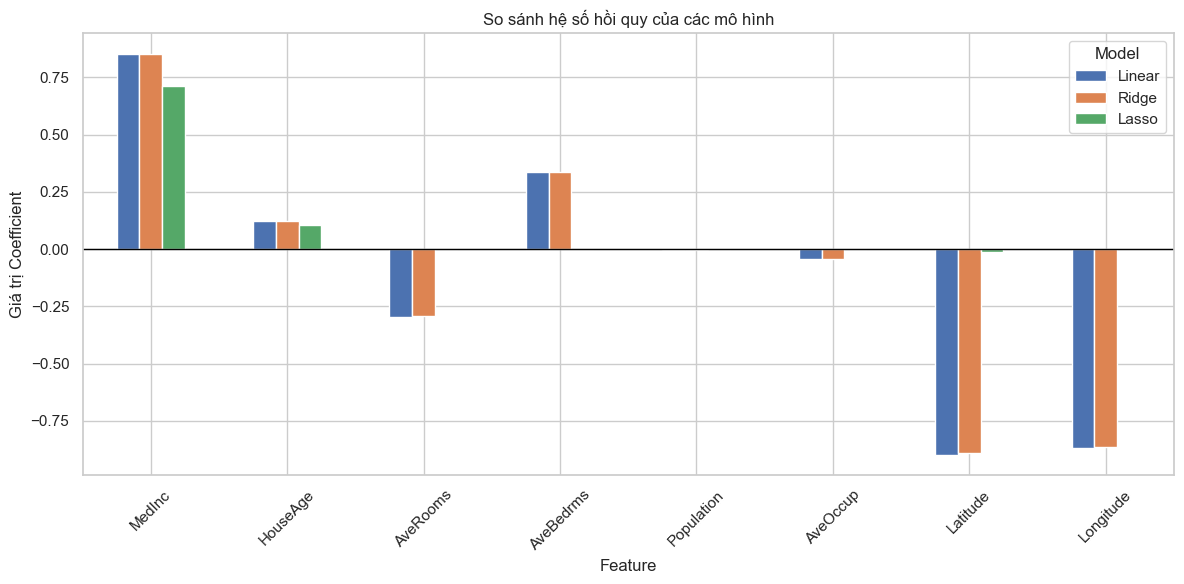

Số coefficient bằng 0 của Lasso: 5


In [15]:
# TODO 6: Trực quan hóa Coefficients
features = X.columns

coef_df = pd.DataFrame({
    "Linear": lr_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
}, index=features)

display(coef_df)

# Vẽ biểu đồ so sánh
ax = coef_df.plot(kind="bar", figsize=(12, 6))

plt.title("So sánh hệ số hồi quy của các mô hình")
plt.xlabel("Feature")
plt.ylabel("Giá trị Coefficient")
plt.xticks(rotation=45)
plt.axhline(0, color="black", linewidth=1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

print("Số coefficient bằng 0 của Lasso:", np.sum(lasso_model.coef_ == 0))

**Trả lời 6:**

Khi quan sát hệ số của ba mô hình, em thấy Ridge có xu hướng làm các hệ số nhỏ lại so với Linear Regression, nhưng đa số hệ số vẫn khác 0. Điều này đúng với ý tưởng của L2 regularization: phạt hệ số lớn để mô hình ổn định hơn, nhưng không thường xuyên loại bỏ hẳn đặc trưng.

Với Lasso, một số hệ số có thể bị ép về đúng 0. Đây là điểm đặc biệt của L1 regularization. Khi hệ số của một feature bằng 0, mô hình gần như không dùng feature đó trong dự đoán.

Tính chất này thường được dùng cho feature selection, tức là chọn ra những đặc trưng quan trọng hơn và loại bỏ bớt các đặc trưng ít đóng góp. Điều này giúp mô hình gọn hơn và dễ diễn giải hơn.

---
## (Bonus) Task 7 — Tìm siêu tham số tối ưu với GridSearchCV

Ở Task 5, chúng ta chỉ chọn bừa `alpha=10.0` và `alpha=0.1`. Làm sao để biết `alpha` bao nhiêu là tốt nhất cho bộ dữ liệu này?

### Yêu cầu
Sử dụng `GridSearchCV` để chạy thử nghiệm nghiệm chéo (Cross-Validation) tìm giá trị `alpha` tối ưu cho Ridge Regression trong danh sách: `[0.1, 1.0, 10.0, 100.0]`.

### Gợi ý
- Import: `from sklearn.model_selection import GridSearchCV`.
- Cấu hình param grid: `param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}`.
- In ra `grid_search.best_params_` sau khi fit trên tập Train.

In [16]:
# TODO Bonus: GridSearchCV cho Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {
    "alpha": [0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_search.fit(X_train_scaled, y_train)

print(f"Alpha tốt nhất cho Ridge: {grid_search.best_params_}")
print(f"Best CV score - negative RMSE: {grid_search.best_score_:.4f}")
print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")

best_ridge_model = grid_search.best_estimator_

rmse_best_ridge, r2_best_ridge = evaluate_model(
    best_ridge_model,
    X_test_scaled,
    y_test
)

print(f"Best Ridge Test - RMSE: {rmse_best_ridge:.4f}, R2: {r2_best_ridge:.4f}")

Alpha tốt nhất cho Ridge: {'alpha': 0.1}
Best CV score - negative RMSE: -0.7205
Best CV RMSE: 0.7205
Best Ridge Test - RMSE: 0.7456, R2: 0.5758


**Nhận xét Bonus:**

GridSearchCV giúp thử nhiều giá trị `alpha` khác nhau và chọn giá trị tốt nhất dựa trên cross-validation. Cách này hợp lý hơn việc chọn alpha thủ công, vì mỗi dataset có mức regularization phù hợp khác nhau.

Nếu alpha quá nhỏ, Ridge gần giống Linear Regression và regularization yếu. Nếu alpha quá lớn, các hệ số bị thu nhỏ quá mạnh, mô hình có thể bị underfitting. Vì vậy dùng GridSearchCV giúp chọn alpha cân bằng hơn.

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không bị lỗi NameError hay SyntaxError.
- [ ] Đã hoàn thiện bước Scale dữ liệu cẩn thận, không có Data Leakage.
- [ ] Đã trực quan hóa đủ các biểu đồ ở Task 2 và Task 6.
- [ ] Đã trả lời phần nhận xét bằng Text ở các câu hỏi (Task 2, Task 6).
